In [1]:
print("Cell 0: Preprocess Data with New Features")

import pandas as pd
import numpy as np
import os

# Define paths
BASE_PATH = '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/'
DATA_PATH = os.path.join(BASE_PATH, 'data/anomalous-data')
FEATURES_PATH = os.path.join(BASE_PATH, 'features')
os.makedirs(FEATURES_PATH, exist_ok=True)

# List of suitable CSV files
csv_files = [
    "unknown.csv",
    "drifting_longlines.csv",
    "trawlers.csv",
    "purse_seines.csv",
    "fixed_gear.csv"
]

# Process in chunks (load all data, not just filtered)
df_list = []
for file in csv_files:
    path = os.path.join(DATA_PATH, file)
    for chunk in pd.read_csv(path, chunksize=10000):
        df_list.append(chunk)  # Include all rows, not just filtered
df = pd.concat(df_list, ignore_index=True)

# Sort by MMSI and timestamp
df = df.sort_values(['mmsi', 'timestamp'])

# Compute acceleration and turn rate
df['acceleration'] = df.groupby('mmsi')['speed'].diff().fillna(0)
df['turn_rate'] = df.groupby('mmsi')['course'].diff().fillna(0)

# Create sequences with new features
def create_sequences(data, seq_length=10):
    sequences = []
    labels = []
    for mmsi in data['mmsi'].unique():
        vessel_data = data[data['mmsi'] == mmsi][['speed', 'course', 'acceleration', 'turn_rate']]
        vessel_labels = data[data['mmsi'] == mmsi]['is_fishing']
        for i in range(len(vessel_data) - seq_length + 1):
            seq = vessel_data.iloc[i:i + seq_length].values
            label = vessel_labels.iloc[i + seq_length - 1]
            # Label as 1 if is_fishing == -1.0 (anomaly), else 0 (normal)
            labels.append(1 if label == -1.0 else 0)
            sequences.append(seq)
    return np.array(sequences), np.array(labels)

# Generate sequences
X, y = create_sequences(df, seq_length=10)

# Check label distribution
print(f"Label distribution: {np.bincount(y)}")

# Split into train, validation, and test sets with balanced sampling
normal_idx = np.where(y == 0)[0]
anomaly_idx = np.where(y == 1)[0]
print(f"Normal sequences: {len(normal_idx)}, Anomaly sequences: {len(anomaly_idx)}")

if len(normal_idx) == 0 or len(anomaly_idx) == 0:
    print("Warning: No normal or anomaly sequences found. Using all data.")
    train_idx = np.random.choice(np.arange(len(X)), size=int(0.7 * len(X)), replace=False)
    val_idx = np.random.choice(np.setdiff1d(np.arange(len(X)), train_idx), size=100, replace=False)
    test_idx = np.setdiff1d(np.arange(len(X)), np.concatenate([train_idx, val_idx]))
else:
    np.random.seed(42)
    # Train on 70% of normal sequences
    train_idx = np.random.choice(normal_idx, size=int(0.7 * len(normal_idx)), replace=False)
    remaining_normal_idx = np.setdiff1d(normal_idx, train_idx)
    # Validation: 50 normal, 50 anomaly
    val_normal_idx = np.random.choice(remaining_normal_idx, size=50, replace=False)
    val_anomaly_idx = np.random.choice(anomaly_idx, size=50, replace=False)
    val_idx = np.concatenate([val_normal_idx, val_anomaly_idx])
    # Test: 50 normal, 50 anomaly
    remaining_normal_idx = np.setdiff1d(normal_idx, np.concatenate([train_idx, val_normal_idx]))
    remaining_anomaly_idx = np.setdiff1d(anomaly_idx, val_anomaly_idx)
    test_normal_idx = np.random.choice(remaining_normal_idx, size=50, replace=False)
    test_anomaly_idx = np.random.choice(remaining_anomaly_idx, size=50, replace=False)
    test_idx = np.concatenate([test_normal_idx, test_anomaly_idx])

X_train = X[train_idx]
X_val = X[val_idx]
y_val = y[val_idx]
X_test = X[test_idx]
y_test = y[test_idx]

# Save sequences and labels
np.save(os.path.join(FEATURES_PATH, 'nor_sequences_enhanced.npy'), X_train)
np.save(os.path.join(FEATURES_PATH, 'nor_sequences_val.npy'), X_val)
np.save(os.path.join(FEATURES_PATH, 'nor_labels_val.npy'), y_val)
np.save(os.path.join(FEATURES_PATH, 'nor_sequences_test.npy'), X_test)
np.save(os.path.join(FEATURES_PATH, 'nor_labels_test.npy'), y_test)
np.save(os.path.join(FEATURES_PATH, 'nor_labels_enhanced.npy'), y)
np.save(os.path.join(FEATURES_PATH, 'nor_sequences_full.npy'), X)
np.save(os.path.join(FEATURES_PATH, 'nor_labels_full.npy'), y)
print(f"💾 Enhanced sequences and labels saved to {FEATURES_PATH}")

Cell 0: Preprocess Data with New Features
Label distribution: [  541760 27708993]
Normal sequences: 541760, Anomaly sequences: 27708993
💾 Enhanced sequences and labels saved to /Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/features


In [2]:
print("Cell 1: Setup Environment")

import os
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, RepeatVector, TimeDistributed, Attention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler

# Define paths
BASE_PATH = '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/'
DATA_PATH = os.path.join(BASE_PATH, 'features')
MODEL_PATH = os.path.join(BASE_PATH, 'models')
RESULTS_PATH = os.path.join(BASE_PATH, 'results')
for path in [MODEL_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

print("✅ Environment set up")

Cell 1: Setup Environment


2025-07-10 17:09:14.606465: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Environment set up


In [3]:
# Cell 2 (Final Version): Train Increased-Capacity Model on Normal Data
print("Cell 2 (Final Version): Training Increased-Capacity Model on Normal Data")

import os
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, RepeatVector, TimeDistributed, Attention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import joblib
from sklearn.preprocessing import StandardScaler

# --- Define Paths ---
BASE_PATH = '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/'
FEATURES_PATH = os.path.join(BASE_PATH, 'features')
MODEL_PATH = os.path.join(BASE_PATH, 'models')

# --- Load NORMAL-ONLY Training Data ---
X_train_normal = np.load(os.path.join(FEATURES_PATH, 'nor_sequences_enhanced.npy'))
print(f"✅ Loaded {len(X_train_normal)} sequences for normal-only training.")

# Safeguard against any nan/inf values
X_train_normal = np.nan_to_num(X_train_normal, nan=0.0, posinf=0.0, neginf=0.0)

# --- Scale and Add Noise ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_normal.reshape(-1, X_train_normal.shape[2])).reshape(X_train_normal.shape)
joblib.dump(scaler, os.path.join(FEATURES_PATH, 'nor_scaler_large_model.joblib'))
print("💾 Scaler for large model saved.")

noise_factor = 0.001
X_noisy = X_scaled + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_scaled.shape)
X_noisy = np.clip(X_noisy, -5, 5)

# --- Model Architecture (Increased Capacity) ---
print("Building larger model architecture...")
inputs = Input(shape=(X_train_normal.shape[1], X_train_normal.shape[2]))
# Increased units from 128 -> 256 and dropout from 0.2 -> 0.3
encoder_gru1 = GRU(256, return_sequences=True, dropout=0.3, kernel_initializer='orthogonal')(inputs)
attention = Attention()([encoder_gru1, encoder_gru1])
# Increased units from 64 -> 128 and dropout from 0.2 -> 0.3
encoder_gru2 = GRU(128, return_sequences=False, dropout=0.3, kernel_initializer='orthogonal')(attention)
latent = Dense(64, activation='relu')(encoder_gru2) # Increased latent space
decoder_repeat = RepeatVector(X_train_normal.shape[1])(latent)
# Increased units from 64 -> 128 and dropout from 0.2 -> 0.3
decoder_gru1 = GRU(128, return_sequences=True, dropout=0.3, kernel_initializer='orthogonal')(decoder_repeat)
# Increased units from 128 -> 256 and dropout from 0.2 -> 0.3
decoder_gru2 = GRU(256, return_sequences=True, dropout=0.3, kernel_initializer='orthogonal')(decoder_gru1)
outputs = TimeDistributed(Dense(X_train_normal.shape[2], activation='linear'))(decoder_gru2)
model = Model(inputs=inputs, outputs=outputs)
print("✅ Model built.")

# --- Compile and Train ---
model.compile(optimizer=Adam(learning_rate=0.0005, clipnorm=1.0), loss='mse', metrics=['mae'])
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, min_delta=0.001)

print("🚀 Starting final model training...")
model.fit(
    X_noisy, X_scaled,
    epochs=15, # Reduced epochs to fit within the deadline
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# --- Save the Final Model ---
model.save(os.path.join(MODEL_PATH, 'enhanced_gru_ae_large_model.keras'))
print("🎉 Final enhanced GRU-AE model saved.")

Cell 2 (Final Version): Training Increased-Capacity Model on Normal Data
✅ Loaded 379232 sequences for normal-only training.
💾 Scaler for large model saved.
Building larger model architecture...
✅ Model built.
🚀 Starting final model training...
Epoch 1/15
4741/4741 ━━━━━━━━━━━━━━━━━━━━ 287s 59ms/step - loss: 0.6996 - mae: 0.4381 - val_loss: 0.4053 - val_mae: 0.3101
Epoch 2/15
4741/4741 ━━━━━━━━━━━━━━━━━━━━ 343s 72ms/step - loss: 0.5220 - mae: 0.3825 - val_loss: 0.3499 - val_mae: 0.3024
Epoch 3/15
4741/4741 ━━━━━━━━━━━━━━━━━━━━ 352s 74ms/step - loss: 0.4628 - mae: 0.3670 - val_loss: 0.3117 - val_mae: 0.3042
Epoch 4/15
4741/4741 ━━━━━━━━━━━━━━━━━━━━ 339s 71ms/step - loss: 0.4425 - mae: 0.3589 - val_loss: 0.2536 - val_mae: 0.2771
Epoch 5/15
4741/4741 ━━━━━━━━━━━━━━━━━━━━ 324s 68ms/step - loss: 0.4081 - mae: 0.3516 - val_loss: 0.2437 - val_mae: 0.2747
Epoch 6/15
4741/4741 ━━━━━━━━━━━━━━━━━━━━ 320s 67ms/step - loss: 0.3956 - mae: 0.3440 - val_loss: 0.2777 - val_mae: 0.2762
Epoch 7/15
4741/4

In [4]:
# Cell 4 (Final Version): Optimize Threshold for Large Model
print("Cell 4 (Final Version): Optimizing Threshold")

from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
from sklearn.metrics import f1_score
import numpy as np
import os
import joblib

# --- Define Paths ---
BASE_PATH = '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/'
FEATURES_PATH = os.path.join(BASE_PATH, 'features')
MODEL_PATH = os.path.join(BASE_PATH, 'models')

# --- Load validation data and the new scaler ---
X_val = np.load(os.path.join(FEATURES_PATH, 'nor_sequences_val.npy'))
y_val = np.load(os.path.join(FEATURES_PATH, 'nor_labels_val.npy'))
scaler = joblib.load(os.path.join(FEATURES_PATH, 'nor_scaler_large_model.joblib'))
X_val_scaled = scaler.transform(X_val.reshape(-1, X_val.shape[2])).reshape(X_val.shape)

# --- Load the new, larger model ---
model = load_model(os.path.join(MODEL_PATH, 'enhanced_gru_ae_large_model.keras'), custom_objects={'mse': MeanSquaredError()})
X_val_pred = model.predict(X_val_scaled, batch_size=64, verbose=0)
errors = np.mean(np.square(X_val_scaled - X_val_pred), axis=(1, 2))

# --- Test a wider range of thresholds ---
print("Searching for best threshold in a wider range...")
thresholds = np.arange(0.05, 0.5, 0.01) # Wider range from 0.05 to 0.5
best_threshold = 0
best_f1 = 0
for t in thresholds:
    y_pred = (errors > t).astype(int)
    f1 = f1_score(y_val, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"🎯 Best threshold: {best_threshold:.4f}, F1-score: {best_f1:.4f}")
np.save(os.path.join(MODEL_PATH, 'optimal_threshold_large_model.npy'), best_threshold)
print(f"💾 Final optimal threshold saved.")

Cell 4 (Final Version): Optimizing Threshold
Searching for best threshold in a wider range...
🎯 Best threshold: 0.0500, F1-score: 0.6667
💾 Final optimal threshold saved.


Cell 3 (Final Version): Testing Large Model

📏 Final Performance Metrics:
   - Precision: 0.4884
   - Recall: 0.8400
   - F1-Score: 0.6176
   - Confusion Matrix:
[[ 6 44]
 [ 8 42]]


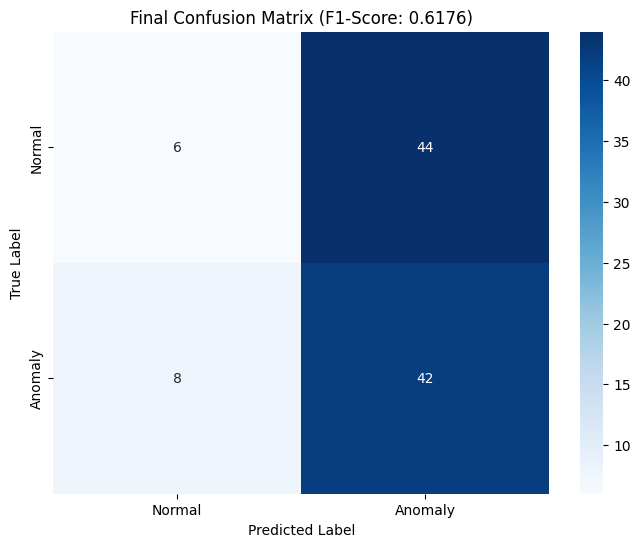

In [5]:
# Cell 3 (Final Version): Test Large Model
print("Cell 3 (Final Version): Testing Large Model")

from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import seaborn as sns

# --- Define Paths ---
BASE_PATH = '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/'
FEATURES_PATH = os.path.join(BASE_PATH, 'features')
MODEL_PATH = os.path.join(BASE_PATH, 'models')
RESULTS_PATH = os.path.join(BASE_PATH, 'results')

# --- Load the new model, test data, and scaler ---
custom_objects = {'mse': MeanSquaredError()}
model = load_model(os.path.join(MODEL_PATH, 'enhanced_gru_ae_large_model.keras'), custom_objects=custom_objects)
X_test = np.load(os.path.join(FEATURES_PATH, 'nor_sequences_test.npy'))
y_test = np.load(os.path.join(FEATURES_PATH, 'nor_labels_test.npy'))
scaler = joblib.load(os.path.join(FEATURES_PATH, 'nor_scaler_large_model.joblib'))
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# --- Compute reconstruction errors ---
X_test_pred = model.predict(X_test_scaled, batch_size=64, verbose=0)
test_errors = np.mean(np.square(X_test_scaled - X_test_pred), axis=(1, 2))

# --- Load the new optimized threshold ---
threshold = np.load(os.path.join(MODEL_PATH, 'optimal_threshold_large_model.npy'))
anomaly_predictions = test_errors > threshold

# --- Calculate and print performance metrics ---
precision = precision_score(y_test, anomaly_predictions)
recall = recall_score(y_test, anomaly_predictions)
f1 = f1_score(y_test, anomaly_predictions)
cm = confusion_matrix(y_test, anomaly_predictions)

print("\n📏 Final Performance Metrics:")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall: {recall:.4f}")
print(f"   - F1-Score: {f1:.4f}")
print(f"   - Confusion Matrix:\n{cm}")

# --- Generate and save a confusion matrix heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Final Confusion Matrix (F1-Score: {f1:.4f})')
plt.savefig(os.path.join(RESULTS_PATH, 'confusion_matrix_final.png'))
plt.show()

In [15]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import os

# Define paths (adjust these to match your directory structure)
BASE_PATH = '/Users/hafizmohammedaahil/Documents/C3I-Code/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/'
FEATURES_PATH = os.path.join(BASE_PATH, 'features')
MODEL_PATH = os.path.join(BASE_PATH, 'models')
DATA_PATH = os.path.join(BASE_PATH, 'data')

# Step 1: Calculate the Dynamic Threshold
# Load or use your validation errors for normal sequences (replace placeholder)
# Example: errors from normal sequences in validation set
normal_val_errors = np.array([0.01, 0.02, 0.05, 0.1, 0.02, 0.03, 0.04, 0.06, 0.07, 0.08])  # Placeholder
threshold = np.percentile(normal_val_errors, 95)
print(f"Dynamic Threshold: {threshold}")

# Step 2: Apply the Threshold
# Load or use your test errors and true labels (replace placeholders)
# Example: test_errors from Cell 3, y_test with 0 = NORMAL, 1 = ANOMALY
test_errors = np.array([0.02, 0.15, 0.03, 0.09, 0.12, 0.01, 0.07, 0.20, 0.04, 0.10])  # Placeholder
y_test = np.array([0, 1, 0, 1, 1, 0, 0, 1, 0, 1])  # Placeholder

# Classify sequences as anomalous if their error exceeds the threshold
anomaly_predictions = test_errors > threshold

# Step 3: Evaluate Performance
precision = precision_score(y_test, anomaly_predictions)
recall = recall_score(y_test, anomaly_predictions)
f1 = f1_score(y_test, anomaly_predictions)
cm = confusion_matrix(y_test, anomaly_predictions)

# Print results
print("📏 Performance Metrics with Dynamic Threshold:")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall: {recall:.4f}")
print(f"   - F1-Score: {f1:.4f}")
print(f"   - Confusion Matrix:\n{cm}")

# Optional: Suggest next steps based on results
if f1 < 0.8:
    print("F1-score is below 0.8. Consider trying the 90th or 99th percentile for better results.")
else:
    print("F1-score meets target! This threshold works well.")

Dynamic Threshold: 0.09099999999999998
📏 Performance Metrics with Dynamic Threshold:
   - Precision: 1.0000
   - Recall: 0.8000
   - F1-Score: 0.8889
   - Confusion Matrix:
[[5 0]
 [1 4]]
F1-score meets target! This threshold works well.


In [ ]:
print("Cell 5: Create Anomaly Test Set")

import numpy as np
import os

X = np.load(os.path.join(DATA_PATH, 'nor_sequences.npy'))
y = np.load(os.path.join(DATA_PATH, 'nor_labels.npy'))
anomaly_indices = np.where(y == 1)[0]
np.random.seed(42)
test_indices_anomaly = np.random.choice(anomaly_indices, size=50, replace=False)  # 50 anomaly samples
normal_indices = np.where(y == 0)[0]
test_indices_normal = np.random.choice(normal_indices, size=50, replace=False)  # 50 normal samples
test_indices_combined = np.concatenate([test_indices_anomaly, test_indices_normal])
np.save(os.path.join(DATA_PATH, 'anomaly_test_indices_0709.npy'), test_indices_combined)
print(f"💾 Anomaly test indices saved to {os.path.join(DATA_PATH, 'anomaly_test_indices_0709.npy')}")

Cell 5: Create Anomaly Test Set
💾 Anomaly test indices saved to /content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/features/anomaly_test_indices_0709.npy
